# Lab1. Part 2: infographic of relationships between  characters in the Game of Thrones

**Brief description**

[Game of Thrones](https://en.wikipedia.org/wiki/Game_of_Thrones) is arguably one of the biggest pop culture phenomena to hit the public zeitgeist in the last decade.

In this **Part 2 of the Lab 1**, we will need to analyze data on relationships (family ties) between characters in the Game of Thrones  and then build a network (a set of graphs representing the main Houses - Dynasties).




The *game-of-thrones-characters-groups.json* dataset stores about characters and their relationships (family ties).

We will build and visualize a undirected graph where nodes are characters (the central node will be the House - Dynasty name) and and edges represent dynasty membership.

Let's imagine that we need to summerize relationships between various characters in the Game of Thrones.

We have *game-of-thrones-characters-groups.json* dataset that captures data about character relationships.

In [138]:
import json
import io
import os

In [139]:
file_name = "data/game-of-thrones-characters-groups.json"
path="data"

In [140]:
json_files = [os.path.join(root, name) 
              for root, dirs, files in os.walk(path) 
              for name in files 
              if name.endswith((".json"))] #If we needed to read several files extensions: if name.endswith((".ext1", ".ext2"))

print('Number of JSON files ready to be loaded: ' + str(len(json_files)))

Number of JSON files ready to be loaded: 1


In [141]:
print('Path to the first file: '+json_files[0])

Path to the first file: data/game-of-thrones-characters-groups.json


In [142]:
#Open the file using the name of the json file witn open() function
#Read the json file using load() and put the json data into a variable.
with open(json_files[0]) as f:
   json_data = json.load(f)

In [143]:
json_data

{'groups': [{'name': 'Stark',
   'characters': ['Arya Stark',
    'Benjen Stark',
    'Bran Stark',
    'Catelyn Stark',
    'Eddard Stark',
    'Ghost',
    'Grey Wind',
    'Jon Snow',
    'Lady',
    'Nymeria',
    'Rickon Stark',
    'Robb Stark',
    'Sansa Stark',
    'Shaggydog',
    'Summer']},
  {'name': 'Targaryen',
   'characters': ['Daenerys Targaryen',
    'Drogon',
    'Rhaegal',
    'Viserion',
    'Viserys Targaryen']},
  {'name': 'Baratheon',
   'characters': ['Joffrey Baratheon',
    'Myrcella Baratheon',
    'Renly Baratheon',
    'Robert Baratheon',
    'Selyse Baratheon',
    'Shireen Baratheon',
    'Stannis Baratheon',
    'Tommen Baratheon',
    'Gendry']},
  {'name': 'Lannister',
   'characters': ['Cersei Lannister',
    'Jaime Lannister',
    'Kevan Lannister',
    'Lancel Lannister',
    'Tyrion Lannister',
    'Tywin Lannister']},
  {'name': "Night's Watch",
   'characters': ['Alliser Thorne',
    'Eddison Tollett',
    'Grenn',
    'Jeor Mormont',
    'Karl

## Task 1.

1.1 Create **Dynasty Class** by using the template below:

In [144]:
class Dynasty:
    def __init__(self,name):
        self._name=name # House name, for.ex."Martell"
        self.characters=[] # Family members ("Doran Martell","Ellaria Sand","Nymeria Sand",...)


    @property
    def name(self): # getter for the private instance attribute _name
        return self._name

    @name.setter
    def name(self, value):
        if value=="":
            raise ValueError('Name is empty')

        self._name = value

    def append(self, ch): # to append character to the House (during reading data from JSON-file)
         if type(ch) is not str:
             raise TypeError('Ch is not of type str')

         self.characters.append(ch)

    def __iter__(self): # to loop throw the list of characters via IN operator (for ex. for person in house: ....)
         for ch in self.characters:
             yield ch

    def __contains__(self, ch): # to check if the character belongs to the house (for ex., if person in house ...)
        return ch in self.characters

    def __str__(self): # to print like print(house) - > displat the house's name
        return f"This is the house of {self._name}!"
    
    def getStrength(self): # return N of family members in this house (int)
        return len(self.characters)

1.2 Use the code below to check that your Dynasty class meets all requirement

In [145]:
for data in json_data['groups']:
    house = Dynasty(data['name'])
    for character in data['characters']:
        house.append(character)
    print(house)
    print("Our members:")
    for person in house:
        print(person)
    print(f"We have {house.getStrength()} family members!!!")


This is the house of Stark!
Our members:
Arya Stark
Benjen Stark
Bran Stark
Catelyn Stark
Eddard Stark
Ghost
Grey Wind
Jon Snow
Lady
Nymeria
Rickon Stark
Robb Stark
Sansa Stark
Shaggydog
Summer
We have 15 family members!!!
This is the house of Targaryen!
Our members:
Daenerys Targaryen
Drogon
Rhaegal
Viserion
Viserys Targaryen
We have 5 family members!!!
This is the house of Baratheon!
Our members:
Joffrey Baratheon
Myrcella Baratheon
Renly Baratheon
Robert Baratheon
Selyse Baratheon
Shireen Baratheon
Stannis Baratheon
Tommen Baratheon
Gendry
We have 9 family members!!!
This is the house of Lannister!
Our members:
Cersei Lannister
Jaime Lannister
Kevan Lannister
Lancel Lannister
Tyrion Lannister
Tywin Lannister
We have 6 family members!!!
This is the house of Night's Watch!
Our members:
Alliser Thorne
Eddison Tollett
Grenn
Jeor Mormont
Karl Tanner
Maester Aemon
Olly
Othell Yarwyck
Pypar
Qhorin Halfhand
Rast
Samwell Tarly
Yoren
We have 13 family members!!!
This is the house of Dothraki!

## Task 2.

2.1 Create **GameOfThronesGraph Class** to store data abot all Houses by using the temlate below:

In [146]:
class GameOfThronesGraph:
    def __init__(self, corpus):
        #initialisation of dictionary that will store all houses. They keys are Houses' (Dynasty) names, the values are Dynasty objects.
        self.houses = {}
        #Load the house corpus
        for data_item in corpus:
            dynasty = Dynasty(data_item['name'])
            for character in data_item['characters']:
                dynasty.append(character)
            self.houses[data_item['name']] = dynasty


    def __iter__(self):  # for the case like the following: for house in GameOfThronesHouses:
        for e in self.houses.keys():
            yield self.houses[e]

    def __contains__(self, h):  #Check if h (house's name) is a key in dict houses - the house is in the graph
        return h in self.houses.keys()

In [147]:
corpusData=json_data['groups']

In [148]:
GameOfThronesHouses=GameOfThronesGraph(corpusData)

In [149]:
for house in GameOfThronesHouses:
    print(house)

This is the house of Stark!
This is the house of Targaryen!
This is the house of Baratheon!
This is the house of Lannister!
This is the house of Night's Watch!
This is the house of Dothraki!
This is the house of Greyjoy!
This is the house of Tyrell!
This is the house of Wildlings!
This is the house of Martell!
This is the house of Frey!
This is the house of Tully!
This is the house of White Walkers!
This is the house of Include!


2.2 Let's add a visualization to show the power level of each dynasty.
Run the code below.

In [150]:
visualisationData={}
legendData=[]
for house in GameOfThronesHouses:
  print(house)
  print(f"Strength: {house.getStrength()}")
  visualisationData[house.name]=house.getStrength()
  legendData.append(house.name)

This is the house of Stark!
Strength: 15
This is the house of Targaryen!
Strength: 5
This is the house of Baratheon!
Strength: 9
This is the house of Lannister!
Strength: 6
This is the house of Night's Watch!
Strength: 13
This is the house of Dothraki!
Strength: 5
This is the house of Greyjoy!
Strength: 4
This is the house of Tyrell!
Strength: 4
This is the house of Wildlings!
Strength: 11
This is the house of Martell!
Strength: 7
This is the house of Frey!
Strength: 3
This is the house of Tully!
Strength: 2
This is the house of White Walkers!
Strength: 5
This is the house of Include!
Strength: 65


In [151]:
visualisationData

{'Stark': 15,
 'Targaryen': 5,
 'Baratheon': 9,
 'Lannister': 6,
 "Night's Watch": 13,
 'Dothraki': 5,
 'Greyjoy': 4,
 'Tyrell': 4,
 'Wildlings': 11,
 'Martell': 7,
 'Frey': 3,
 'Tully': 2,
 'White Walkers': 5,
 'Include': 65}

In [152]:
legendData

['Stark',
 'Targaryen',
 'Baratheon',
 'Lannister',
 "Night's Watch",
 'Dothraki',
 'Greyjoy',
 'Tyrell',
 'Wildlings',
 'Martell',
 'Frey',
 'Tully',
 'White Walkers',
 'Include']

In [153]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

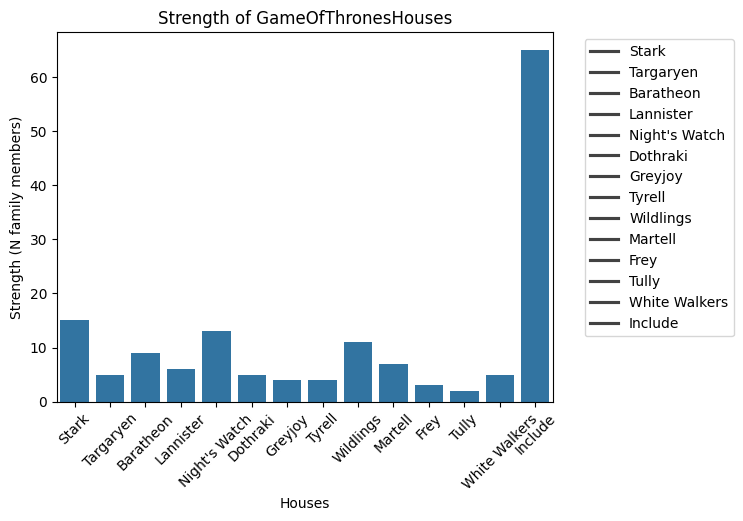

In [154]:
#Configure your x and y values from the dictionary:
x= list(visualisationData.keys())
y=list(visualisationData.values())

#Create the graph = create seaborn barplot
ax=sns.barplot(x=x,y=y)

#specfiy axis labels
ax.legend(legendData)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1.05, 1))
ax.set(xlabel='Houses',
       ylabel='Strength (N family members)',
       title='Strength of GameOfThronesHouses')

plt.xticks(rotation=45)
#display barplot
plt.show()

## Task 3.

Now we need to create the graph with a suitable Python library  based on our graph data stored in *GameOfThronesHouses*.

[NetworkX](https://networkx.org/) is a Python package for the creation, manipulation, and study of the structure, dynamics, and functions of complex networks.

In [155]:
import networkx as nx

In [156]:
g = nx.Graph() # graph initialization

Add nodes into the Graph (add characters into Game Of Thrones)

Let's use *seaborn.color_palette* and create a dictionary to specify different color for different families.

In [157]:
import seaborn as sns

N_houses=0
colorKeys=[]
for house in GameOfThronesHouses:
    if house.name!="Include":
        N_houses+=1
        colorKeys.append(house.name)
sns.color_palette("husl", N_houses) # N_houses colors

[(0.9677975592919913, 0.44127456009157356, 0.5358103155058701),
 (0.9218528551477547, 0.500345433264, 0.19606247053399534),
 (0.756593795426372, 0.58660455674609, 0.19460548454202936),
 (0.6280838378584804, 0.6317149736053096, 0.19371846323785552),
 (0.44127702936426016, 0.6747986506725627, 0.19278677787286805),
 (0.19925855442314272, 0.6935861010390585, 0.43494846713408325),
 (0.20730980534421067, 0.6820252887361699, 0.5931178995944008),
 (0.213603436221035, 0.6724447149771248, 0.6900417229996091),
 (0.2218708221705632, 0.6590814541823624, 0.7990680761766646),
 (0.38670894369284947, 0.6148978276981065, 0.9585912355668605),
 (0.7049741506310939, 0.5248938690186019, 0.9581527270311664),
 (0.9538763597142671, 0.3594595647605631, 0.95756585161213),
 (0.9637107389395935, 0.4095260281088575, 0.7436447221919831)]

In [158]:
list(sns.color_palette("husl", N_houses))

[(0.9677975592919913, 0.44127456009157356, 0.5358103155058701),
 (0.9218528551477547, 0.500345433264, 0.19606247053399534),
 (0.756593795426372, 0.58660455674609, 0.19460548454202936),
 (0.6280838378584804, 0.6317149736053096, 0.19371846323785552),
 (0.44127702936426016, 0.6747986506725627, 0.19278677787286805),
 (0.19925855442314272, 0.6935861010390585, 0.43494846713408325),
 (0.20730980534421067, 0.6820252887361699, 0.5931178995944008),
 (0.213603436221035, 0.6724447149771248, 0.6900417229996091),
 (0.2218708221705632, 0.6590814541823624, 0.7990680761766646),
 (0.38670894369284947, 0.6148978276981065, 0.9585912355668605),
 (0.7049741506310939, 0.5248938690186019, 0.9581527270311664),
 (0.9538763597142671, 0.3594595647605631, 0.95756585161213),
 (0.9637107389395935, 0.4095260281088575, 0.7436447221919831)]

In [159]:
colorKeys

['Stark',
 'Targaryen',
 'Baratheon',
 'Lannister',
 "Night's Watch",
 'Dothraki',
 'Greyjoy',
 'Tyrell',
 'Wildlings',
 'Martell',
 'Frey',
 'Tully',
 'White Walkers']

In [160]:
nodeColors=dict(zip(colorKeys, [tuple(int(c*255) for c in cs) for cs in sns.color_palette("husl", N_houses)]))
nodeColors

{'Stark': (246, 112, 136),
 'Targaryen': (235, 127, 49),
 'Baratheon': (192, 149, 49),
 'Lannister': (160, 161, 49),
 "Night's Watch": (112, 172, 49),
 'Dothraki': (50, 176, 110),
 'Greyjoy': (52, 173, 151),
 'Tyrell': (54, 171, 175),
 'Wildlings': (56, 168, 203),
 'Martell': (98, 156, 244),
 'Frey': (179, 133, 244),
 'Tully': (243, 91, 244),
 'White Walkers': (245, 104, 189)}

In [161]:
#this doesn't work for us because Pyvis requires strings (hexadecimal) as values for the color attribute, not RGB tuples. 
# We need to convert RGB tuples to hexadecimal strings later
#for house in GameOfThronesHouses:
    #if house.name!="Include":
        #g.add_node(house.name, size=house.getStrength(), color=nodeColors[house.name])
    

Add nodes to the graph (via *g.add_node()*) with their names and sizes only.

First we need to add main nodes - houses, and add other nodes - family members after that.

In [162]:
for house in GameOfThronesHouses:
    if house.name!="Include":
        # add the house's name as a node to the graph g (houses's strength values is used as a node's size)
        g.add_node(house.name, size=house.getStrength(), color=nodeColors[house.name])

In [163]:
for node, attributes in g.nodes(data=True): # run this code to check your code above
    print(f"Node: {node}, Attributes: {attributes}")

Node: Stark, Attributes: {'size': 15, 'color': (246, 112, 136)}
Node: Targaryen, Attributes: {'size': 5, 'color': (235, 127, 49)}
Node: Baratheon, Attributes: {'size': 9, 'color': (192, 149, 49)}
Node: Lannister, Attributes: {'size': 6, 'color': (160, 161, 49)}
Node: Night's Watch, Attributes: {'size': 13, 'color': (112, 172, 49)}
Node: Dothraki, Attributes: {'size': 5, 'color': (50, 176, 110)}
Node: Greyjoy, Attributes: {'size': 4, 'color': (52, 173, 151)}
Node: Tyrell, Attributes: {'size': 4, 'color': (54, 171, 175)}
Node: Wildlings, Attributes: {'size': 11, 'color': (56, 168, 203)}
Node: Martell, Attributes: {'size': 7, 'color': (98, 156, 244)}
Node: Frey, Attributes: {'size': 3, 'color': (179, 133, 244)}
Node: Tully, Attributes: {'size': 2, 'color': (243, 91, 244)}
Node: White Walkers, Attributes: {'size': 5, 'color': (245, 104, 189)}


Now we can add nodes - family members from each house

In [164]:
for house in GameOfThronesHouses:
    if house.name!="Include":
        # add each character as a node to the graph g 
        g.add_nodes_from(house)
        

In [165]:
for node, attributes in g.nodes(data=True): # run this code to check your code above
    print(f"Node: {node}, Attributes: {attributes}")

Node: Stark, Attributes: {'size': 15, 'color': (246, 112, 136)}
Node: Targaryen, Attributes: {'size': 5, 'color': (235, 127, 49)}
Node: Baratheon, Attributes: {'size': 9, 'color': (192, 149, 49)}
Node: Lannister, Attributes: {'size': 6, 'color': (160, 161, 49)}
Node: Night's Watch, Attributes: {'size': 13, 'color': (112, 172, 49)}
Node: Dothraki, Attributes: {'size': 5, 'color': (50, 176, 110)}
Node: Greyjoy, Attributes: {'size': 4, 'color': (52, 173, 151)}
Node: Tyrell, Attributes: {'size': 4, 'color': (54, 171, 175)}
Node: Wildlings, Attributes: {'size': 11, 'color': (56, 168, 203)}
Node: Martell, Attributes: {'size': 7, 'color': (98, 156, 244)}
Node: Frey, Attributes: {'size': 3, 'color': (179, 133, 244)}
Node: Tully, Attributes: {'size': 2, 'color': (243, 91, 244)}
Node: White Walkers, Attributes: {'size': 5, 'color': (245, 104, 189)}
Node: Arya Stark, Attributes: {}
Node: Benjen Stark, Attributes: {}
Node: Bran Stark, Attributes: {}
Node: Catelyn Stark, Attributes: {}
Node: Eddard

Add edges (*myEdges=[]*):
1. add connections between a House and its family members
2. add connections between members belonging to the same House (not presented in my examples)

In [166]:
myEdges=[]

In [167]:
for house in GameOfThronesHouses:
    if house.name!="Include":
        for person in house:
            myEdges.append((house.name,person))

In [168]:
print("Connections between a House and its family members:") # run this code to check your code above
myEdges

Connections between a House and its family members:


[('Stark', 'Arya Stark'),
 ('Stark', 'Benjen Stark'),
 ('Stark', 'Bran Stark'),
 ('Stark', 'Catelyn Stark'),
 ('Stark', 'Eddard Stark'),
 ('Stark', 'Ghost'),
 ('Stark', 'Grey Wind'),
 ('Stark', 'Jon Snow'),
 ('Stark', 'Lady'),
 ('Stark', 'Nymeria'),
 ('Stark', 'Rickon Stark'),
 ('Stark', 'Robb Stark'),
 ('Stark', 'Sansa Stark'),
 ('Stark', 'Shaggydog'),
 ('Stark', 'Summer'),
 ('Targaryen', 'Daenerys Targaryen'),
 ('Targaryen', 'Drogon'),
 ('Targaryen', 'Rhaegal'),
 ('Targaryen', 'Viserion'),
 ('Targaryen', 'Viserys Targaryen'),
 ('Baratheon', 'Joffrey Baratheon'),
 ('Baratheon', 'Myrcella Baratheon'),
 ('Baratheon', 'Renly Baratheon'),
 ('Baratheon', 'Robert Baratheon'),
 ('Baratheon', 'Selyse Baratheon'),
 ('Baratheon', 'Shireen Baratheon'),
 ('Baratheon', 'Stannis Baratheon'),
 ('Baratheon', 'Tommen Baratheon'),
 ('Baratheon', 'Gendry'),
 ('Lannister', 'Cersei Lannister'),
 ('Lannister', 'Jaime Lannister'),
 ('Lannister', 'Kevan Lannister'),
 ('Lannister', 'Lancel Lannister'),
 ('Lan

In [169]:
g.add_edges_from(myEdges) # run this code to add edges to our graph g

In [170]:
list(g.edges)# run this code  to check the edges in our graph g

[('Stark', 'Arya Stark'),
 ('Stark', 'Benjen Stark'),
 ('Stark', 'Bran Stark'),
 ('Stark', 'Catelyn Stark'),
 ('Stark', 'Eddard Stark'),
 ('Stark', 'Ghost'),
 ('Stark', 'Grey Wind'),
 ('Stark', 'Jon Snow'),
 ('Stark', 'Lady'),
 ('Stark', 'Nymeria'),
 ('Stark', 'Rickon Stark'),
 ('Stark', 'Robb Stark'),
 ('Stark', 'Sansa Stark'),
 ('Stark', 'Shaggydog'),
 ('Stark', 'Summer'),
 ('Targaryen', 'Daenerys Targaryen'),
 ('Targaryen', 'Drogon'),
 ('Targaryen', 'Rhaegal'),
 ('Targaryen', 'Viserion'),
 ('Targaryen', 'Viserys Targaryen'),
 ('Baratheon', 'Joffrey Baratheon'),
 ('Baratheon', 'Myrcella Baratheon'),
 ('Baratheon', 'Renly Baratheon'),
 ('Baratheon', 'Robert Baratheon'),
 ('Baratheon', 'Selyse Baratheon'),
 ('Baratheon', 'Shireen Baratheon'),
 ('Baratheon', 'Stannis Baratheon'),
 ('Baratheon', 'Tommen Baratheon'),
 ('Baratheon', 'Gendry'),
 ('Lannister', 'Cersei Lannister'),
 ('Lannister', 'Jaime Lannister'),
 ('Lannister', 'Kevan Lannister'),
 ('Lannister', 'Lancel Lannister'),
 ('Lan

In [171]:
len(list(g.edges)) # N of edges =89!!! check yours :)

89

In [172]:
from pyvis.network import Network

All networks (graphs) must be instantiated as a *Network* class instance

In [173]:
GameOfThronesNet = Network(
                bgcolor ="#242020",
                font_color = "white",
                height = "1000px",
                width = "100%",
                notebook=True,
                cdn_resources = "remote")

In [174]:
# generate the graph
GameOfThronesNet.from_nx(g)  

Specify colors for the Houses and their members by using the code below:

In [175]:
for node in GameOfThronesNet.nodes:
    if node["id"] in GameOfThronesHouses:
        # Convert RGB to hexadecimal string
        node["color"] = '#%02x%02x%02x' % nodeColors[node["id"]]
    else:
        for house in GameOfThronesHouses: 
            if house.name !="Include":# apple the coloer of the House to this family member
                if node["id"] in house:
                    node["color"] = '#%02x%02x%02x' % nodeColors[house.name]

In [176]:
GameOfThronesNet.nodes

[{'color': '#f67088',
  'size': 15,
  'id': 'Stark',
  'label': 'Stark',
  'shape': 'dot',
  'font': {'color': 'white'}},
 {'color': '#f67088',
  'size': 10,
  'id': 'Arya Stark',
  'label': 'Arya Stark',
  'shape': 'dot',
  'font': {'color': 'white'}},
 {'color': '#f67088',
  'size': 10,
  'id': 'Benjen Stark',
  'label': 'Benjen Stark',
  'shape': 'dot',
  'font': {'color': 'white'}},
 {'color': '#f67088',
  'size': 10,
  'id': 'Bran Stark',
  'label': 'Bran Stark',
  'shape': 'dot',
  'font': {'color': 'white'}},
 {'color': '#f67088',
  'size': 10,
  'id': 'Catelyn Stark',
  'label': 'Catelyn Stark',
  'shape': 'dot',
  'font': {'color': 'white'}},
 {'color': '#f67088',
  'size': 10,
  'id': 'Eddard Stark',
  'label': 'Eddard Stark',
  'shape': 'dot',
  'font': {'color': 'white'}},
 {'color': '#f67088',
  'size': 10,
  'id': 'Ghost',
  'label': 'Ghost',
  'shape': 'dot',
  'font': {'color': 'white'}},
 {'color': '#f67088',
  'size': 10,
  'id': 'Grey Wind',
  'label': 'Grey Wind',
 

 Display the network as an interactive HTML file using the *show()* method.

In [177]:
GameOfThronesNet.show("GameOfThronesNet.html",notebook=False)

GameOfThronesNet.html


![image.png](attachment:image.png)


![image.png](attachment:image.png)

Task 4.

Now you are ready to deploy your visualization App as a **web service**. Let's develop a **Streamlit application** (**lab1app2.py**) and deploy it on Streamlit Community Cloud.

The application includes 3 tabs, each of which displays different data (visualization). See required results below.

![image.png](attachment:image.png)

![image.png](attachment:image.png)

![image.png](attachment:image.png)